# Vanilla RAG at 20,000 characters - standalone

Re-runs the vanilla RAG baseline with the prompt context raised from **5,000 to 20,000
characters**, matching the budget the 5-channel fusion system gets (`document_head` = 20,000).

### Why this notebook needs nothing from the DGX

Vanilla RAG is **zero-shot**. It touches exactly three things per document: `text`, `country`
and `doc_id`. No interventions, no gold labels, no cross-validation folds, no `Dataset.load()`.

So the entire gold-rebuild chain (`gold.py`, `master.py`) is irrelevant here, and with it the risk
of the intervention set drifting and invalidating the comparison. Everything the run needs is in
two files:

| File | What it is |
|---|---|
| `corpus_documents.json.gz` | all 221 documents, text extracted with pypdf, 12 scanned ones OCR'd |
| `eric_strategies.json` | the 73 ERIC strategies and their 9 categories |

**Scoring is deliberately deferred.** It needs the gold interventions, costs seconds of CPU, and
can be done any time afterwards. The expensive GPU work produces per-document rows that are
independent of the gold, so nothing is lost by separating them.

---
### What changes vs the original 9.2 run

| | Original | Here |
|---|---|---|
| `max_context_chars` | 5,000 | **20,000** |
| `top_k` | 20 | 20 (unchanged) |
| chunk size / overlap | 1,000 / 200 | unchanged |
| encoder | multilingual-e5-large | unchanged |
| generator | Qwen2.5-7B-Instruct | unchanged (4-bit for T4) |
| prompt text | - | unchanged, verbatim |

Two honest differences to record in the write-up: the model is **4-bit quantised** to fit a 16 GB
T4, and the 12 OCR'd documents were re-OCR'd locally with Tesseract 5.4.0, so their text is not
byte-identical to the original run's. That is 12 of 221 documents.


## 1 - Install and check the GPU


In [1]:
!pip -q install 'transformers>=4.44' 'accelerate>=0.33' 'bitsandbytes>=0.43' \
                'sentence-transformers>=3.0' pandas numpy

import torch
print('torch', torch.__version__, '| cuda', torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print('gpu  ', p.name, f'{p.total_memory/1e9:.1f} GB', f'sm_{p.major}{p.minor}')
    if p.major < 8:
        print()
        print('No bf16 hardware on this GPU (T4 is sm_75). Qwen2.5 overflows in fp16 and')
        print('emits "!!!!!" - so we load 4-bit NF4 and smoke-test before the full run.')
else:
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 70.5 MB/s eta 0:00:00
torch 2.11.0+cu128 | cuda True
gpu   NVIDIA L4 23.7 GB sm_89


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path

BASE = Path('/content/drive/MyDrive')

## 2 - Load the corpus

Upload `corpus_documents.json.gz` and `eric_strategies.json`, or mount Drive and point at them.


In [6]:
from pathlib import Path
import gzip, json

# from google.colab import drive; drive.mount('/content/drive')
BASE = Path('/content')                     # <-- EDIT if the files live elsewhere

CORPUS = BASE / 'corpus_documents.json.gz'
ERIC   = BASE / 'eric_strategies.json'
for f in (CORPUS, ERIC):
    if not f.exists():
        raise SystemExit(f'missing: {f}')

docs = json.loads(gzip.decompress(CORPUS.read_bytes()).decode('utf8'))
eric = json.loads(ERIC.read_text(encoding='utf8'))
print(f'{len(docs)} documents, {sum(d["n_chars"] for d in docs.values()):,} characters')
print(f'{eric["counts"]["strategies"]} strategies in {eric["counts"]["categories"]} categories')


221 documents, 19,796,545 characters
73 strategies in 9 categories


### Verify the corpus


In [7]:
import pandas as pd

rows = []
for c in sorted({d['country'] for d in docs.values()}):
    cd = [d for d in docs.values() if d['country'] == c]
    rows.append({'country': c, 'documents': len(cd),
                 'OCR': sum(1 for d in cd if d['source'] == 'ocr'),
                 'chars': sum(d['n_chars'] for d in cd),
                 'median_chars': int(pd.Series([d['n_chars'] for d in cd]).median())})
tab = pd.DataFrame(rows).sort_values('documents', ascending=False)
tab.loc['TOTAL'] = ['TOTAL', tab.documents.sum(), tab.OCR.sum(), tab.chars.sum(), '']
display(tab)
print('EXPECTED: 221 documents across 13 countries, 12 OCR-recovered')


,country,documents,OCR,chars,median_chars
0,Bangladesh,23,3,2987303,72412
1,Brazil,23,0,2883023,35080
2,China,23,0,275128,3040
7,Pakistan,20,2,1425568,42098
4,India,18,1,1379955,47193
6,Malawi,18,0,2534673,47754
3,Ghana,17,0,1078813,21755
12,Zambia,15,0,556505,4414
9,Russia,15,1,2325458,52578
8,Philippines,14,1,1283839,44579


EXPECTED: 221 documents across 13 countries, 12 OCR-recovered


## 3 - Configuration

`top_k=20` at 1,000 chars per chunk yields exactly 20,000 characters, so retrieval depth and the
context cap now agree. In the original run `top_k` was already 20, but the 5,000-char cap threw
away three quarters of everything that had been retrieved.


In [10]:
MODEL             = 'Qwen/Qwen2.5-7B-Instruct'
MAX_NEW_TOKENS    = 600
BATCH_SIZE        = 1

# One fixed query for the original task.
# Kept only as experiment metadata; it is NOT used for retrieval.
QUERY = ('antimicrobial resistance intervention: its name, objectives, activities, '
         'implementation and monitoring')

# Full-document experiment:
# Qwen receives docs[d]["text"] directly.
OUT = BASE / 'vanilla_full_document'
OUT.mkdir(parents=True, exist_ok=True)

print('per-document rows ->', OUT)
print('already written   :', len(list(OUT.glob('*.json'))), 'of', len(docs))

per-document rows -> /content/vanilla_full_document
already written   : 0 of 221


## 4 - The pipeline, verbatim from `vanilla_rag.py`

`chunk()` is from `sota_rag.py:43`; `prompt()` and the JSON parsing are from `vanilla_rag.py`.
Reproduced inline so the notebook has no repo dependency - the text is unchanged.


In [11]:
import re, numpy as np

STRATEGIES = [s['strategy'] for s in eric['strategies']]
S2C = {s['strategy']: s['category'] for s in eric['strategies']}

TAXONOMY = '\n'.join(
    f'{i}. {s}  ({S2C[s]})'
    for i, s in enumerate(STRATEGIES, 1)
)

import unicodedata

def norm(s):
    """eric.norm - verbatim."""
    s = unicodedata.normalize('NFKD', str(s))
    s = s.replace('\u2019', "'").replace('\u2018', "'")
    return re.sub(r'[^a-z0-9]', '', s.lower())

_BY_NORM = {norm(s): s for s in STRATEGIES}

def canonical(label):
    """eric.canonical - verbatim."""
    if not label or not str(label).strip():
        return None

    key = norm(label)
    hit = _BY_NORM.get(key)

    if hit:
        return hit

    for cand_norm, cand in _BY_NORM.items():
        if (
            key
            and (key in cand_norm or cand_norm in key)
            and abs(len(key) - len(cand_norm)) <= 4
        ):
            return cand

    return None


def build_prompt(doc):
    ctx = doc["text"]

    return (
        f'You are a policy analyst coding a national health policy document from '
        f'{doc["country"]} into a structured database.\n\n'
        f'THE 73 ERIC STRATEGIES (choose only from this numbered list):\n{TAXONOMY}\n\n'
        f'FULL DOCUMENT:\n{ctx}\n\n'
        'Record the main intervention this document establishes.\n\n'
        'Field instructions:\n'
        '- name: the official title of the programme, in English\n'
        '- summary: 2-3 sentences on objectives, who runs it, and main activities\n'
        '- focus: exactly ONE of: AMR, AMU, IPC, Antimicrobial Stewardship, '
        'Public Education & Awareness Campaign\n'
        '- level: exactly ONE of: Macro, Meso, Micro\n'
        '- maturity: exactly ONE of: Developed, Implemented, Evaluated\n'
        '- eric_codes: a list of 8 to 12 strategy names copied EXACTLY from the '
        'numbered list above. Use ONLY the strategy names, never the category '
        'names shown in brackets. Never write placeholder text.\n\n'
        'Reply with a single JSON object using those six keys and real values.\nJSON:'
    )


def parse_reply(reply):
    m = re.search(r'\{.*\}', reply, re.S)

    rec = {
        'name': '',
        'summary': '',
        'eric_codes': []
    }

    if m:
        try:
            obj = json.loads(m.group(0))

            codes = [
                canonical(c)
                for c in obj.get('eric_codes', [])
            ]

            rec = {
                'name': str(obj.get('name', '')).strip(),
                'summary': str(obj.get('summary', '')).strip(),
                'focus': obj.get('focus'),
                'level': obj.get('level'),
                'maturity': obj.get('maturity'),
                'eric_codes': [c for c in codes if c]
            }

        except json.JSONDecodeError:
            pass

    return rec


print(
    'taxonomy block:',
    len(TAXONOMY),
    'chars |',
    len(STRATEGIES),
    'strategies'
)

taxonomy block: 5100 chars | 73 strategies


## 6 - Load the generator, then smoke-test

**Do not skip this.** Three documents takes a couple of minutes and tells you whether an overnight
run is worth starting. If the output is exclamation marks, that is the fp16 overflow and the run
is worthless.


In [12]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch, time

tok = AutoTokenizer.from_pretrained(
    MODEL,
    padding_side='left'
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb_config,
    device_map='auto',
    attn_implementation='sdpa'
)

model.eval()

print(
    f'GPU memory allocated: '
    f'{torch.cuda.memory_allocated()/1e9:.1f} GB'
)

print('ready')

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

GPU memory allocated: 5.6 GB
ready


In [13]:
token_lengths = []

for d in sorted(docs):
    n = len(tok(
        docs[d]["text"],
        add_special_tokens=False
    )["input_ids"])
    token_lengths.append((d, n))

print('documents:', len(token_lengths))
print('min tokens:', min(n for _, n in token_lengths))
print('max tokens:', max(n for _, n in token_lengths))
print('median tokens:', sorted(n for _, n in token_lengths)[len(token_lengths)//2])

too_long = [(d, n) for d, n in token_lengths if n > 8192]

print('>8192 tokens:', len(too_long))
print('examples:', too_long[:10])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (199484 > 131072). Running this sequence through the model will result in indexing errors


documents: 221
min tokens: 64
max tokens: 289335
median tokens: 10296
>8192 tokens: 121
examples: [('Bangladesh_01', 11196), ('Bangladesh_04', 9275), ('Bangladesh_06', 37551), ('Bangladesh_07', 123956), ('Bangladesh_08', 14974), ('Bangladesh_10', 27200), ('Bangladesh_11', 24704), ('Bangladesh_12', 39137), ('Bangladesh_17', 199484), ('Bangladesh_18', 10181)]


In [14]:
# Check how many documents exceed Qwen's 131,072-token context limit

LIMIT = 131072

too_long = [
    (d, n)
    for d, n in token_lengths
    if n > LIMIT
]

print(f'Total documents : {len(token_lengths)}')
print(f'Within limit    : {len(token_lengths) - len(too_long)}')
print(f'Over 131072     : {len(too_long)}')

print()
print('Documents over the model limit:')

for d, n in too_long:
    print(f'{d}: {n:,} tokens')

Total documents : 221
Within limit    : 213
Over 131072     : 8

Documents over the model limit:
Bangladesh_17: 199,484 tokens
Bangladesh_22: 151,715 tokens
Brazil_02: 237,870 tokens
Brazil_26: 181,202 tokens
Kosovo_04: 260,298 tokens
Malawi_17: 214,176 tokens
Philippines_07: 146,685 tokens
Russia_07: 289,335 tokens


In [15]:
def _decode_batch(prompts):
    """
    Generate one or more prompts with Qwen.

    For the full-document experiment we do NOT truncate the document
    to an arbitrary 2048/4096/8192-token limit here.

    The tokenizer is allowed to report an error if a document is too
    long for the model's supported context window.
    """

    texts = [
        tok.apply_chat_template(
            [{'role': 'user', 'content': p}],
            tokenize=False,
            add_generation_prompt=True
        )
        for p in prompts
    ]

    e = tok(
        texts,
        return_tensors='pt',
        padding=True,
        truncation=False
    ).to(model.device)

    with torch.no_grad():
        g = model.generate(
            **e,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tok.pad_token_id
        )

    input_lengths = e['attention_mask'].sum(dim=1).tolist()

    outputs = []

    for i, input_len in enumerate(input_lengths):
        generated = g[i][int(input_len):]

        outputs.append(
            tok.decode(
                generated,
                skip_special_tokens=True
            )
        )

    return outputs


def generate_many(prompts, batch_size=1):
    """
    Generate responses for a list of prompts.

    batch_size=1 is recommended for the full-document experiment
    because documents can be very large.
    """

    out = []

    for i in range(0, len(prompts), batch_size):

        batch = prompts[i:i + batch_size]

        replies = _decode_batch(batch)

        out.extend(replies)

        # Release temporary tensors between documents/batches.
        del replies
        torch.cuda.empty_cache()

    return out


print('generation functions ready')

generation functions ready


In [16]:
probe = sorted(docs)[:3]
t0 = time.time()
prompts = [build_prompt(docs[d]) for d in probe]
print('prompt tokens:', [len(tok(p)['input_ids']) for p in prompts])
replies = generate_many(prompts, batch_size=1)
dt = time.time() - t0

recs = {d: parse_reply(r) for d, r in zip(probe, replies)}
for d, r in recs.items():
    print()
    print('---', d, f"({docs[d]['country']})")
    print('  name :', (r.get('name') or '')[:88])
    print('  codes:', len(r.get('eric_codes', [])), r.get('eric_codes', [])[:3])

bang  = sum(1 for r in recs.values() if '!!!' in (r.get('name') or ''))
blank = sum(1 for r in recs.values() if not r.get('eric_codes'))
print()
print(f'{dt:.0f}s for 3 docs -> about {dt/3*len(docs)/3600:.1f} h for all {len(docs)}')
if bang:
    print('FP16 OVERFLOW - do not proceed.')
elif blank == 3:
    print('No codes parsed from any of the three - check the reply format before proceeding.')
else:
    print('Healthy. Proceed to section 7.')


prompt tokens: [12475, 2164, 4789]

--- Bangladesh_01 (Bangladesh)
  name : National Drug Policy 2016
  codes: 1 ['Promote adaptability']

--- Bangladesh_02 (Bangladesh)
  name : Bangladesh Pharmacy Model Initiative
  codes: 2 ['Promote adaptability', 'Use data experts']

--- Bangladesh_03 (Bangladesh)
  name : National Action Plan for Antimicrobial Resistance Containment in Bangladesh
  codes: 3 ['Promote adaptability', 'Use data experts', 'Develop academic partnerships']

32s for 3 docs -> about 0.7 h for all 221
Healthy. Proceed to section 7.


In [17]:
d = 'Bangladesh_02'
p = build_prompt(docs[d])
raw = generate_many([p], batch_size=1)[0]
print('--- RAW MODEL REPLY ---')
print(raw[:1500])
print('\n--- PARSED ---')
print(parse_reply(raw))

import re as _re
m = _re.search(r'\{.*\}', raw, _re.S)
if m:
    try:
        obj = json.loads(m.group(0))
        codes = obj.get('eric_codes', [])
        print(f'\nmodel emitted {len(codes)} codes:')
        for c in codes:
            print(f'   {c!r:55s} -> {canonical(c)!r}')
    except json.JSONDecodeError as e:
        print('\nJSON PARSE FAILED:', e)

--- RAW MODEL REPLY ---
```json
{
  "name": "Bangladesh Pharmacy Model Initiative",
  "summary": "The Bangladesh Pharmacy Model Initiative aims to standardize and accredit private retail drug outlets, enhancing regulatory oversight and consumer access to quality medicines. It is run by the Ministry of Health and Family Welfare with technical support from Management Sciences for Health and funded by DFID.",
  "focus": "Public Education & Awareness Campaign",
  "level": "Macro",
  "maturity": "Implemented",
  "eric_codes": ["Promote adaptability", "Use data experts", "Change infrastructure", "Develop stakeholder interrelationships", "Engage consumers", "Support clinicians", "Train and educate stakeholders", "Use evaluative and iterative strategies"]
}
```

--- PARSED ---
{'name': 'Bangladesh Pharmacy Model Initiative', 'summary': 'The Bangladesh Pharmacy Model Initiative aims to standardize and accredit private retail drug outlets, enhancing regulatory oversight and consumer access to qu

In [21]:
# ============================================================
# SELECT DOCUMENTS FOR FULL-DOCUMENT EXPERIMENT
# ============================================================

MODEL_CONTEXT_LIMIT = 35000

token_dict = dict(token_lengths)

eligible_docs = {
    d for d, n in token_lengths
    if n <= MODEL_CONTEXT_LIMIT
}

excluded_docs = {
    d for d, n in token_lengths
    if n > MODEL_CONTEXT_LIMIT
}

print(f'Eligible documents : {len(eligible_docs)}')
print(f'Excluded documents : {len(excluded_docs)}')

print()
print('Excluded documents:')

for d in sorted(excluded_docs):
    print(f'  {d}: {token_dict[d]:,} tokens')

Eligible documents : 178
Excluded documents : 43

Excluded documents:
  Bangladesh_06: 37,551 tokens
  Bangladesh_07: 123,956 tokens
  Bangladesh_12: 39,137 tokens
  Bangladesh_17: 199,484 tokens
  Bangladesh_22: 151,715 tokens
  Bangladesh_24: 46,075 tokens
  Brazil_02: 237,870 tokens
  Brazil_16: 41,298 tokens
  Brazil_26: 181,202 tokens
  Brazil_32: 62,932 tokens
  Brazil_33: 107,446 tokens
  China_03: 43,180 tokens
  China_27: 65,376 tokens
  Ghana_07: 69,968 tokens
  Ghana_11: 81,074 tokens
  India_06: 48,411 tokens
  India_15: 67,885 tokens
  India_16: 118,618 tokens
  Kosovo_02: 46,050 tokens
  Kosovo_04: 260,298 tokens
  Kosovo_05: 37,271 tokens
  Malawi_02: 66,324 tokens
  Malawi_04: 73,848 tokens
  Malawi_05: 55,025 tokens
  Malawi_09: 83,317 tokens
  Malawi_13: 82,636 tokens
  Malawi_17: 214,176 tokens
  Pakistan_11: 67,065 tokens
  Pakistan_14: 81,509 tokens
  Philippines_06: 43,916 tokens
  Philippines_07: 146,685 tokens
  Philippines_10: 48,525 tokens
  Russia_03: 121,740

In [20]:
# ============================================================
# SMALL FULL-DOCUMENT GPU TEST
# ============================================================

# Test documents at increasing input sizes.
# We select real documents from your corpus so this tests the
# actual full-document setup.

TEST_LIMITS = [16000, 24000, 32000, 40000]

for limit in TEST_LIMITS:

    candidates = [
        (d, n)
        for d, n in token_lengths
        if n <= limit
    ]

    if not candidates:
        print(f'No document available at <= {limit:,} tokens')
        continue

    # Pick the largest document available at this size.
    d, n = max(candidates, key=lambda x: x[1])

    print()
    print('=' * 60)
    print(f'Testing: {d}')
    print(f'Document tokens: {n:,}')
    print('=' * 60)

    prompt = build_prompt(docs[d])

    try:
        t0 = time.time()

        reply = generate_many(
            [prompt],
            batch_size=1
        )[0]

        elapsed = time.time() - t0

        print(f'✓ SUCCESS')
        print(f'Time: {elapsed:.1f}s')
        print(f'Reply length: {len(reply):,} characters')

        # Free memory before the next test
        del prompt
        del reply
        torch.cuda.empty_cache()

    except torch.cuda.OutOfMemoryError:

        print('✗ CUDA OUT OF MEMORY')
        print(
            f'Practical limit is below approximately '
            f'{n:,} document tokens.'
        )

        torch.cuda.empty_cache()
        break

    except Exception as e:

        print(f'✗ ERROR: {type(e).__name__}: {e}')

        torch.cuda.empty_cache()
        break


Testing: Russia_11
Document tokens: 15,935
✓ SUCCESS
Time: 13.4s
Reply length: 710 characters

Testing: Uganda_06
Document tokens: 23,859
✓ SUCCESS
Time: 18.5s
Reply length: 798 characters

Testing: Uganda_04
Document tokens: 30,640
✓ SUCCESS
Time: 19.9s
Reply length: 623 characters

Testing: Uganda_02
Document tokens: 39,231
✓ SUCCESS
Time: 26.4s
Reply length: 842 characters


## 7 - Main run

Resumable. Documents already written to `OUT` are skipped, so a Colab disconnect costs only the
batch in flight. Re-run this cell to continue.


In [22]:
todo = [
    d for d in sorted(eligible_docs)
    if not (OUT / f'{d}.json').exists()
]

print(
    f'{len(todo)} to do, '
    f'{len(eligible_docs) - len(todo)} already written'
)

t0 = time.time()

for i in range(0, len(todo), BATCH_SIZE):

    batch = todo[i:i + BATCH_SIZE]

    prompts = [
        build_prompt(docs[d])
        for d in batch
    ]

    replies = generate_many(
        prompts,
        batch_size=BATCH_SIZE
    )

    for d, r in zip(batch, replies):

        rec = parse_reply(r)

        rec['_raw'] = r[:4000]

        (OUT / f'{d}.json').write_text(
            json.dumps(
                rec,
                ensure_ascii=False
            )
        )

    done = min(i + BATCH_SIZE, len(todo))

    el = time.time() - t0

    print(
        f'  {done}/{len(todo)}  '
        f'{el/60:.1f} min elapsed'
    )

173 to do, 5 already written
  1/173  0.3 min elapsed
  2/173  0.4 min elapsed
  3/173  0.7 min elapsed
  4/173  1.0 min elapsed
  5/173  1.2 min elapsed
  6/173  1.3 min elapsed
  7/173  1.5 min elapsed
  8/173  1.8 min elapsed
  9/173  2.2 min elapsed
  10/173  2.5 min elapsed
  11/173  2.6 min elapsed
  12/173  2.8 min elapsed
  13/173  3.0 min elapsed
  14/173  3.2 min elapsed
  15/173  3.4 min elapsed
  16/173  3.6 min elapsed
  17/173  3.8 min elapsed
  18/173  4.1 min elapsed
  19/173  4.4 min elapsed
  20/173  4.7 min elapsed
  21/173  4.9 min elapsed
  22/173  5.1 min elapsed
  23/173  5.4 min elapsed
  24/173  5.6 min elapsed
  25/173  5.9 min elapsed
  26/173  6.1 min elapsed
  27/173  6.3 min elapsed
  28/173  6.5 min elapsed
  29/173  6.7 min elapsed
  30/173  6.8 min elapsed
  31/173  6.9 min elapsed
  32/173  7.1 min elapsed
  33/173  7.2 min elapsed
  34/173  7.4 min elapsed
  35/173  7.5 min elapsed
  36/173  7.7 min elapsed
  37/173  7.9 min elapsed
  38/173  8.0 min 

## 8 - Package the results

Download `vanilla_rag_20k_rows.json`. Scoring happens separately, against the gold interventions:
extraction F1, classification, and ERIC F1 both **end-to-end** and **isolated** (see the notes on
why RAG's 9.2 is not directly comparable to the ladder's 54.0).


In [23]:
rows = {
    f.stem: json.loads(f.read_text())
    for f in OUT.glob('*.json')
}

blob = {
    'run': 'vanilla_full_document',

    'config': {
        'context_mode': 'full_document',
        'model': MODEL,
        'quantisation': '4bit-nf4',
        'max_new_tokens': MAX_NEW_TOKENS,
        'batch_size': BATCH_SIZE,
        'query': QUERY
    },

    'n_documents': len(rows),
    'rows': rows
}

out_file = BASE / 'vanilla_full_document_rows.json'

out_file.write_text(
    json.dumps(
        blob,
        indent=1,
        ensure_ascii=False
    )
)

print(
    'wrote',
    out_file,
    f'({out_file.stat().st_size / 1e6:.1f} MB)'
)

n_codes = [
    len(r.get('eric_codes', []))
    for r in rows.values()
]

empty = sum(
    1 for n in n_codes
    if n == 0
)

print()
print(
    f'documents with 0 codes: '
    f'{empty}/{len(rows)}'
)

if n_codes:
    print(
        f'codes per document: '
        f'mean {sum(n_codes)/len(n_codes):.1f}, '
        f'min {min(n_codes)}, '
        f'max {max(n_codes)}'
    )

wrote /content/vanilla_full_document_rows.json (0.3 MB)

documents with 0 codes: 0/179
codes per document: mean 6.2, min 1, max 13


In [24]:
# ============================================================
# BACK UP FINAL RESULTS TO GOOGLE DRIVE
# ============================================================

import shutil

DRIVE_RESULTS = BASE / 'vanilla_full_document_results'
DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)

# Copy individual document JSON files
json_files = list(OUT.glob('*.json'))

for f in json_files:
    shutil.copy2(
        f,
        DRIVE_RESULTS / f.name
    )

# Copy the combined results file created in the previous cell
shutil.copy2(
    out_file,
    DRIVE_RESULTS / out_file.name
)

# Create ZIP backup
zip_path = shutil.make_archive(
    str(BASE / 'vanilla_full_document_results'),
    'zip',
    str(DRIVE_RESULTS)
)

print('========================================')
print('RESULTS BACKED UP TO GOOGLE DRIVE')
print('========================================')
print(f'Documents completed : {len(rows)} / {len(docs)}')
print(f'Results folder      : {DRIVE_RESULTS}')
print(f'Combined JSON       : {DRIVE_RESULTS / out_file.name}')
print(f'ZIP backup          : {zip_path}')
print('========================================')

RESULTS BACKED UP TO GOOGLE DRIVE
Documents completed : 179 / 221
Results folder      : /content/vanilla_full_document_results
Combined JSON       : /content/vanilla_full_document_results/vanilla_full_document_rows.json
ZIP backup          : /content/vanilla_full_document_results.zip


In [25]:
import shutil

In [28]:
import shutil
from google.colab import files

shutil.make_archive('/content/vanilla_rag_full_context', 'zip', '/content/vanilla_rag_full_context')
files.download('/content/vanilla_rag_full_context.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/vanilla_rag_20k', 'zip', '/content/vanilla_rag_20k')
print('size:', round(__import__('os').path.getsize('/content/vanilla_rag_20k.zip')/1e6, 2), 'MB')
files.download('/content/vanilla_rag_20k.zip')

size: 0.14 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

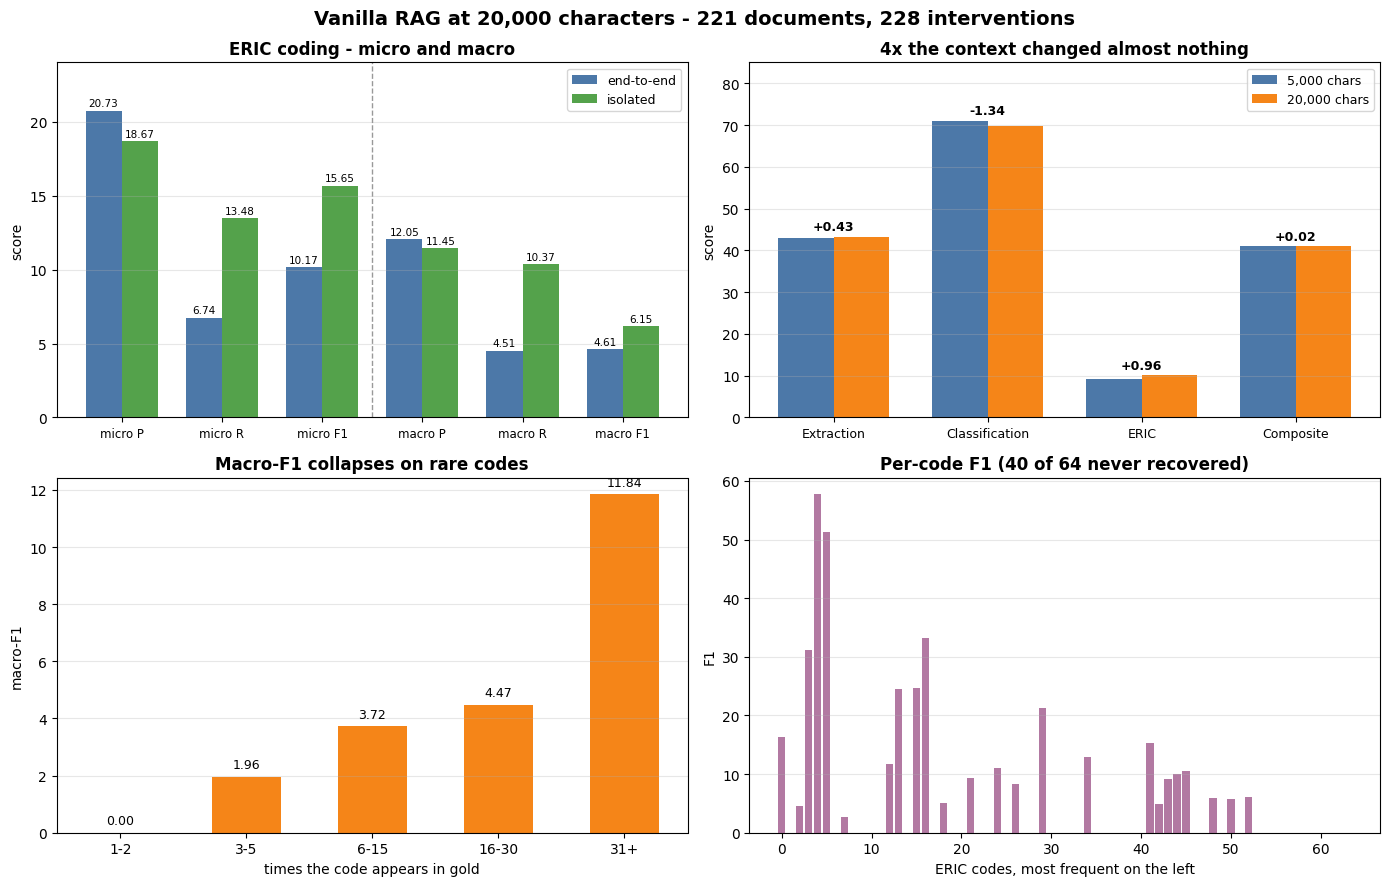

In [ ]:
import numpy as np, matplotlib.pyplot as plt

# ---- vanilla RAG @ 20,000 chars ----
ERIC = {"micro P": 20.73, "micro R": 6.74, "micro F1": 10.17,
        "macro P": 12.05, "macro R": 4.51, "macro F1": 4.61}
ISO  = {"micro P": 18.67, "micro R": 13.48, "micro F1": 15.65,
        "macro P": 11.45, "macro R": 10.37, "macro F1": 6.15}
PIPE = {"Extraction": (42.86, 43.29), "Classification": (71.06, 69.72),
        "ERIC": (9.21, 10.17), "Composite": (41.04, 41.06)}
BANDS = {"1-2": 0.00, "3-5": 1.96, "6-15": 3.72, "16-30": 4.47, "31+": 11.84}
PER_CODE = [16.37,0,4.62,31.17,57.68,51.26,0,2.6,0,0,0,0,11.76,24.44,0,24.72,33.16,0,
            5.13,0,0,9.3,0,0,11.11,0,8.33,0,0,21.25,0,0,0,0,12.9,0,0,0,0,0,0,15.38,
            4.82,9.09,10,10.53,0,0,5.94,0,5.71,0,6.06,0,0,0,0,0,0,0,0,0,0,0]

B, O, G, P = "#4C78A8", "#F58518", "#54A24B", "#B279A2"
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
w = .36

# 1 - micro vs macro
a = ax[0, 0]; x = np.arange(6)
a.bar(x - w/2, list(ERIC.values()), w, label="end-to-end", color=B)
a.bar(x + w/2, list(ISO.values()),  w, label="isolated",   color=G)
for i, (v1, v2) in enumerate(zip(ERIC.values(), ISO.values())):
    a.text(i - w/2, v1 + .3, f"{v1:.2f}", ha="center", fontsize=7.5)
    a.text(i + w/2, v2 + .3, f"{v2:.2f}", ha="center", fontsize=7.5)
a.axvline(2.5, color="#999", ls="--", lw=1)
a.set_xticks(x); a.set_xticklabels(ERIC, fontsize=8.5)
a.set_ylim(0, 24); a.set_ylabel("score")
a.set_title("ERIC coding - micro and macro", fontweight="bold")
a.legend(fontsize=9); a.grid(axis="y", alpha=.3)

# 2 - 5k vs 20k
a = ax[0, 1]; x = np.arange(len(PIPE))
a.bar(x - w/2, [v[0] for v in PIPE.values()], w, label="5,000 chars",  color=B)
a.bar(x + w/2, [v[1] for v in PIPE.values()], w, label="20,000 chars", color=O)
for i, (lo, hi) in enumerate(PIPE.values()):
    a.text(i, max(lo, hi) + 1.5, f"{hi-lo:+.2f}", ha="center",
           fontsize=9, fontweight="bold")
a.set_xticks(x); a.set_xticklabels(PIPE, fontsize=9)
a.set_ylim(0, 85); a.set_ylabel("score")
a.set_title("4x the context changed almost nothing", fontweight="bold")
a.legend(fontsize=9); a.grid(axis="y", alpha=.3)

# 3 - macro-F1 by code frequency
a = ax[1, 0]
a.bar(list(BANDS), list(BANDS.values()), color=O, width=.55)
for i, v in enumerate(BANDS.values()):
    a.text(i, v + .3, f"{v:.2f}", ha="center", fontsize=9)
a.set_xlabel("times the code appears in gold"); a.set_ylabel("macro-F1")
a.set_title("Macro-F1 collapses on rare codes", fontweight="bold")
a.grid(axis="y", alpha=.3)

# 4 - per-code F1
a = ax[1, 1]
a.bar(range(len(PER_CODE)), PER_CODE, color=P)
a.set_xlabel("ERIC codes, most frequent on the left"); a.set_ylabel("F1")
a.set_title(f"Per-code F1 ({sum(1 for v in PER_CODE if v==0)} of 64 never recovered)",
            fontweight="bold")
a.grid(axis="y", alpha=.3)

fig.suptitle("Vanilla RAG at 20,000 characters - 221 documents, 228 interventions",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/vanilla_rag_20k.png", dpi=150, bbox_inches="tight")
plt.show()

Ablation study changing number of characters from 20,000 to 40,000 and then redoing it .

In [ ]:
!rm /content/contexts.json
!rm -rf /content/vanilla_rag_20k